In [1]:
import os
import pystac_client
import rasterio
import rioxarray
import xarray as xr
import xrspatial
from xcube.core.store import new_data_store
from dask.distributed import Client, LocalCluster

In [2]:
os.environ.update({
    "AWS_ACCESS_KEY_ID": "O0M0CUQIDQO9TDZ4D8NR",
    "AWS_SECRET_ACCESS_KEY": "qPUyXs9G6j8on6MY5KPhQNHuA5uZTqxEscrbBCGx",
    "AWS_S3_ENDPOINT": "eodata.dataspace.copernicus.eu",
    "AWS_VIRTUAL_HOSTING": "FALSE",
})

In [3]:
cluster = LocalCluster(
    n_workers=6,
    threads_per_worker=1,
    memory_limit="5GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

'http://127.0.0.1:8787/status'

In [4]:
STAC_URL = "https://stac.dataspace.copernicus.eu/v1"
client = pystac_client.Client.open(STAC_URL)
bbox = [21.05, 35.52, 24.24, 37.43]
search = client.search(
    collections=["cop-dem-glo-30-dged-cog"],
    bbox=bbox,
)
items = list(search.items())
print(f"Found {len(items)} items")

Found 10 items


In [5]:
for item in items:
    print(item.id)

Copernicus_DSM_COG_10_N35_00_E023_00_DEM
Copernicus_DSM_COG_10_N37_00_E024_00_DEM
Copernicus_DSM_COG_10_N37_00_E023_00_DEM
Copernicus_DSM_COG_10_N36_00_E024_00_DEM
Copernicus_DSM_COG_10_N36_00_E023_00_DEM
Copernicus_DSM_COG_10_N35_00_E024_00_DEM
Copernicus_DSM_COG_10_N37_00_E022_00_DEM
Copernicus_DSM_COG_10_N37_00_E021_00_DEM
Copernicus_DSM_COG_10_N36_00_E022_00_DEM
Copernicus_DSM_COG_10_N36_00_E021_00_DEM


In [6]:
%%time
dss = []
for item in items: 
    dss.append(
        rioxarray.open_rasterio(
            item.assets["data"].href,
            chunks={},
            band_as_variable=True,
        )
    )
ds = xr.combine_by_coords(dss, join="outer", fill_value=0.)
ds = ds.rename({"band_1": "dem", "x": "lon", "y": "lat"})
ds

CPU times: user 1.48 s, sys: 166 ms, total: 1.65 s
Wall time: 2.84 s


<xarray.Dataset> Size: 622MB
Dimensions:      (lat: 10800, lon: 14400)
Coordinates:
  * lat          (lat) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon          (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0
    spatial_ref  int64 8B 0
Data variables:
    dem          (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
Attributes:
    AREA_OR_POINT:  Point

In [7]:
%%time
ds["aspect"] = xrspatial.aspect(ds.dem, method="geodesic")
ds["slope"] = xrspatial.slope(ds.dem, method="geodesic")
ds

CPU times: user 9.34 s, sys: 1.59 s, total: 10.9 s
Wall time: 8.52 s


<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 10800, lon: 14400)
Coordinates:
  * lat          (lat) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon          (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0
    spatial_ref  int64 8B 0
Data variables:
    dem          (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    aspect       (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    slope        (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
Attributes:
    AREA_OR_POINT:  Point

In [8]:
%%time
store = new_data_store("file", root="data")
store.write_data(ds, "dem.zarr", replace=True)

/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 2.32 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 28.5 s, sys: 14.5 s, total: 43 s
Wall time: 1min 38s


'dem.zarr'

In [9]:
store.get_open_data_params_schema("dem.zarr")

In [10]:
%%time
ds = store.open_data("dem.zarr")
ds

CPU times: user 24.4 ms, sys: 324 ms, total: 348 ms
Wall time: 343 ms


<xarray.Dataset> Size: 2GB
Dimensions:      (lat: 10800, lon: 14400)
Coordinates:
  * lat          (lat) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon          (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0
Data variables:
    aspect       (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    dem          (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    slope        (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Point

CPU times: user 1.8 s, sys: 246 ms, total: 2.05 s
Wall time: 2.12 s


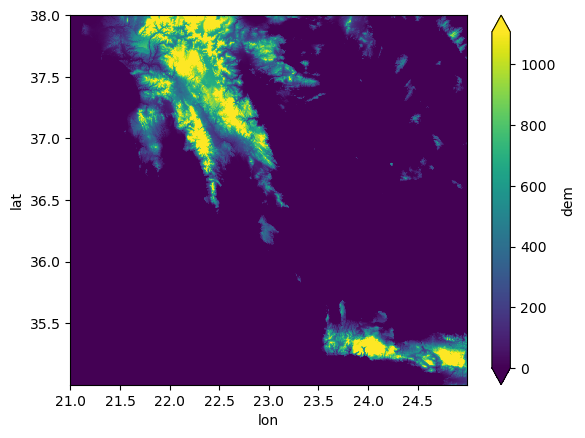

In [11]:
%%time
ds.dem[::10, ::10].plot(robust=True)

CPU times: user 585 ms, sys: 115 ms, total: 700 ms
Wall time: 754 ms


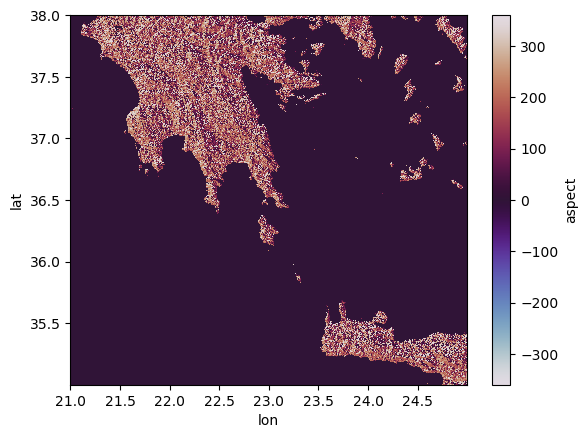

In [12]:
%%time
ds.aspect[::10, ::10].plot(cmap="twilight")

CPU times: user 646 ms, sys: 74.2 ms, total: 720 ms
Wall time: 1.2 s


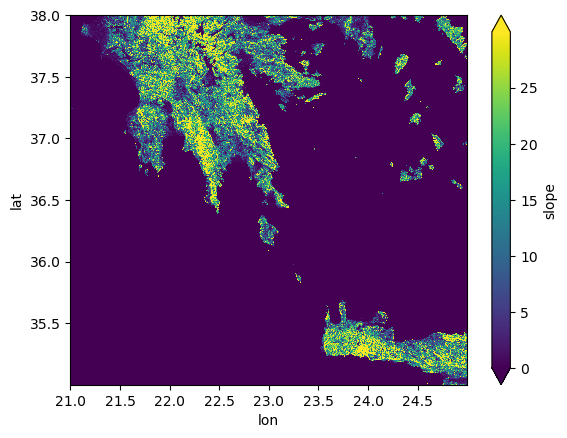

In [13]:
%%time
ds.slope[::10, ::10].plot(robust=True)